In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from common.consts import proteins, thresholds, res_colors

%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
from pathlib import Path
thresholds = np.arange(0.1, 0.50 + 1e-9, 0.01)
all_mfpt = {protein: {th: [] for th in thresholds} for protein in proteins}

def read_colvar_with_fields(path):
    with open(path, "r") as f:
        header = f.readline().strip()
    parts = header.split()
    if len(parts) < 3 or parts[0] != "#!" or parts[1] != "FIELDS":
        raise ValueError(f"Unexpected FIELDS header in {path}: {header}")
    names = parts[2:]
    return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

for protein in proteins:
    base_path = Path(f"../data/{protein}/output")
    for i in range(4000, 4201):
        index_str = f"{i:03}"
        run_path = base_path / f"run_{index_str}" / f"HLDA_COLVAR_{index_str}"
        try:
            df = read_colvar_with_fields(run_path)
        except FileNotFoundError:
            print(f"Missing: {run_path}")
            continue
        if not {"time", "metad.acc", "rmsd"}.issubset(df.columns):
            print(f"Missing required columns in {run_path}")
            continue

        passed = set()
        for _, row in df.iterrows():
            time = row["time"]
            acc = row["metad.acc"]
            rmsd = row["rmsd"]
            predicted = time * acc
            for th in thresholds:
                if th not in passed and rmsd > th:
                    all_mfpt[protein][th].append(predicted)
                    passed.add(th)
            if len(passed) == len(thresholds):
                break



In [3]:
import pickle

with open("../data/mfpt-pace=25000-granular.pkl", "wb") as f:
    pickle.dump(all_mfpt, f)
print(all_mfpt['chignolin'].keys())

p: 0.06606847283274553


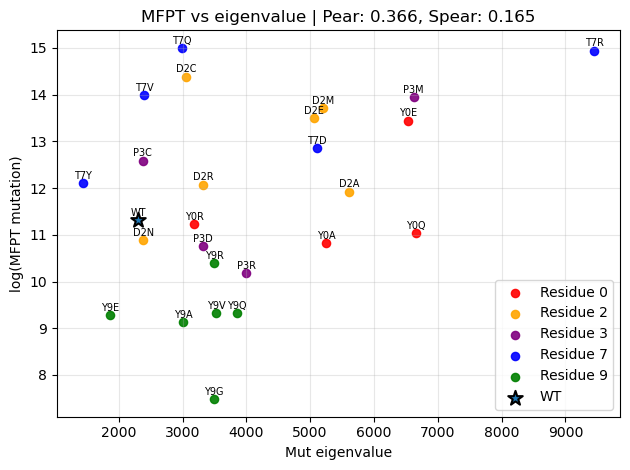

p: 0.0005161630387441321


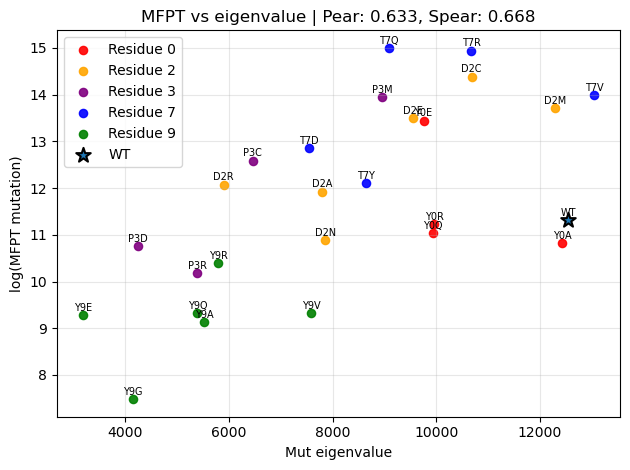

(np.float64(0.6332280506681055), np.float64(0.6683760683760683))

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from common.utils import collect_df  # only for isna in xlabel

def plot_mfpt_corr(df, prop_col, wt_label='WT', group_col='residue_idx',
                   annotate=False, th=None, log_prop=True):
    wt_mfpt = float(df.loc[wt_label, 'mfpt'])
    wt_prop = df.loc[wt_label, prop_col]

    x_all = df[prop_col].to_numpy()
    y_all = np.log(df['mfpt'].to_numpy())
    names = df.index.to_numpy()

    x_map = pd.Series(x_all, index=df.index)
    y_map = pd.Series(y_all, index=df.index)

    pearson, p = stats.pearsonr(x_all, y_all)
    spearman, _ = stats.spearmanr(x_all, y_all)
    print(f"p: {p}")

    for k in sorted(int(k) for k in df[group_col].dropna().unique()):
        sub = df[df[group_col] == k]
        plt.scatter(
            x_map.loc[sub.index].to_numpy(),
            y_map.loc[sub.index].to_numpy(),
            label=f"Residue {k}", s=35, alpha=0.9, c=res_colors.get(k)
        )

    plt.scatter(wt_prop, y_map.loc[wt_label], s=120, marker='*', edgecolors='k', linewidths=1.5, label=wt_label)

    if annotate:
        for xv, yv, name in zip(x_all, y_all, names):
            plt.text(xv, yv + 0.05, name, fontsize=7, ha='center', va='bottom')

    xlabel = (f"Mut {prop_col}" if log_prop and not pd.isna(wt_prop) else prop_col)
    plt.xlabel(xlabel)
    plt.ylabel('log(MFPT mutation)')
    t = f" | Th={th:.3g}" if th is not None else ""
    plt.title(f"MFPT vs {prop_col}{t} | Pear: {pearson:.3g}, Spear: {spearman:.3g}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pearson, spearman



with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

thresholds = np.array(list(all_mfpt['chignolin'].keys()))

df = collect_df(True, all_mfpt, thresholds[1])
plot_mfpt_corr(df, 'eigenvalue', annotate=True)

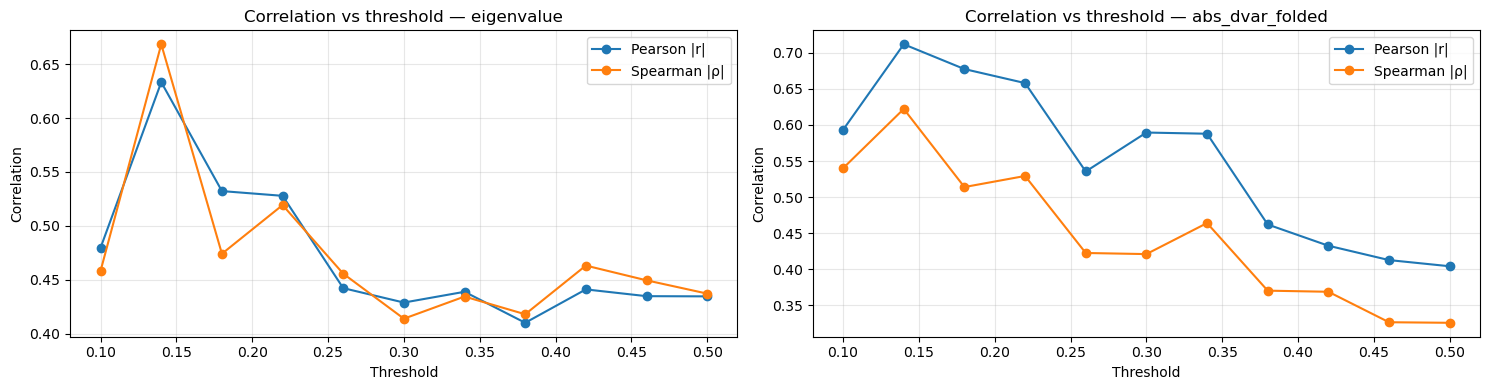

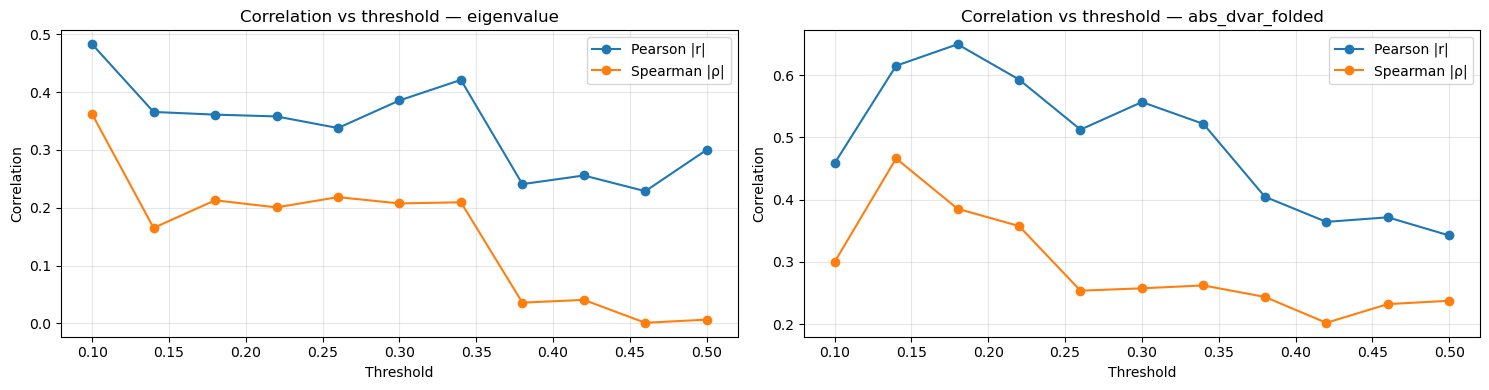

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from common.utils import collect_df

def _safe_abs_corr(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan, np.nan
    x, y = x[mask], y[mask]
    # guard constant inputs
    if np.all(x == x[0]) or np.all(y == y[0]):
        return np.nan, np.nan
    p = stats.pearsonr(x, y)[0]
    s = stats.spearmanr(x, y)[0]
    return abs(p), abs(s)

def plot_corr_vs_thresholds(all_mfpt, is_clearer,
                            props=('eigenvalue', 'abs_dvar_folded'),
                            wt_label='WT'):
    thresholds = np.array(sorted(all_mfpt['chignolin'].keys(), key=float), dtype=float)
    dfs = {th: collect_df(is_clearer, all_mfpt, th) for th in thresholds}

    results = {}
    fig, axes = plt.subplots(1, len(props), figsize=(7.5 * len(props), 4), squeeze=False)

    for pi, prop_col in enumerate(props):
        pearsons, spearmans = [], []
        for th in thresholds:
            df = dfs[th]

            # y = log(WT/mut)
            wt_mfpt = float(df.loc[wt_label, 'mfpt'])
            y_all = np.log(wt_mfpt / pd.to_numeric(df['mfpt'], errors='coerce').to_numpy())

            # x = property values (force to numeric to coerce weird dtypes)
            if prop_col not in df.columns:
                pearsons.append(np.nan); spearmans.append(np.nan); continue
            x_all = pd.to_numeric(df[prop_col], errors='coerce').to_numpy()

            p, s = _safe_abs_corr(x_all, y_all)
            pearsons.append(p); spearmans.append(s)

        ax = axes[0, pi]
        ax.plot(thresholds, pearsons, marker='o', label='Pearson |r|')
        ax.plot(thresholds, spearmans, marker='o', label='Spearman |ρ|')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Correlation')
        ax.set_title(f'Correlation vs threshold — {prop_col}')
        ax.grid(True, alpha=0.3)
        ax.legend()

        results[prop_col] = pd.DataFrame(
            {'threshold': thresholds, 'pearson': pearsons, 'spearman': spearmans}
        ).set_index('threshold')

    plt.tight_layout()
    plt.show()
    return results


results = plot_corr_vs_thresholds(all_mfpt, True)
results = plot_corr_vs_thresholds(all_mfpt, False)


In [ ]:
from scipy import stats, optimize


def fit_exp_ks(samples):
    x = np.array(samples)
    x.sort()

    n = x.size
    ecdf = np.arange(1, n + 1) / n
    def F(t, tau): return 1 - np.exp(-t / tau)
    
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    D, p = stats.kstest(x, "expon", args=(0, tau))
    return tau, p, D
    
def plot_all_mfpt(all_mfpt, proteins, sort_idx=4):
    """
    Sort proteins by ascending MFPT at thresholds[sort_idx] and plot side-by-side
    with independent y-scales and legends.
    """
    thresholds = np.array(list(all_mfpt['chignolin'].keys()))
    sort_idx = max(0, min(sort_idx, len(thresholds) - 1))

    # Collect MFPT (µs)
    series = {p: [] for p in proteins}
    pValues = {p: [] for p in proteins}
    chig = []

    for th in thresholds:
        s = np.sort(np.array(all_mfpt['chignolin'][th]))
        chig_mfpt, lim = estimateMFPT(s, 10)
        chig.append(chig_mfpt / 1e6)

        for p in proteins:
            s = np.sort(np.array(all_mfpt[p][th]))
            mfpt, lim = estimateMFPT(s, 10)
            series[p].append(mfpt / 1e6)
            tau, pValue, D = fit_exp_ks(s[:lim])

            pValues[p].append((pValue, lim))

    def sort_key(p):
        return series[p][sort_idx]

    proteins_sorted = sorted(proteins, key=sort_key)

    mid = (len(proteins_sorted) + 1) // 2
    halves = [proteins_sorted[:mid], proteins_sorted[mid:]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 9), sharey=False)
    ref_th = thresholds[sort_idx]

    for ax, subset, title_suffix in zip(axes, halves, ['First half', 'Second half']):
        for p in subset:
            ax.plot(thresholds, series[p], marker='o', label=p)

            for x, y, (p, lim) in zip(thresholds,series[p], pValues[p]):
                ax.text(x, y, f"{p:.2g}, {lim}", ha='center', va='bottom', fontsize=7)

        ax.plot(thresholds, chig, linestyle='--', linewidth=2, label='chignolin')
        ax.set_xlabel('Threshold')
        ax.set_title(f'{title_suffix}')
        ax.set_yscale('log')
        ax.legend(fontsize=8, ncol=1)
        ax.grid(True)

    axes[0].set_ylabel('MFPT (µs)')
    fig.suptitle(f'MFPT vs Threshold — sorted by MFPT at {ref_th:.3g}')

    plt.tight_layout()
    plt.show()

plot_all_mfpt(all_mfpt, proteins)


NameError: name 'estimateMFPT' is not defined

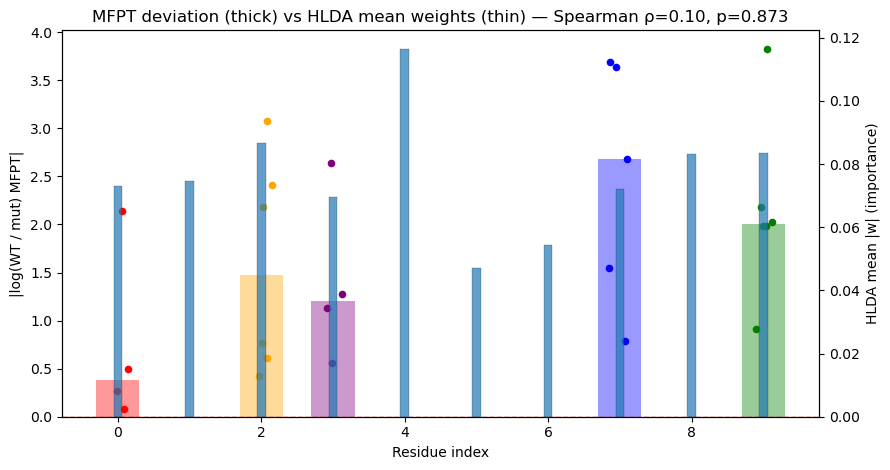

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

importance = {4:0.1165, 2:0.0868, 9:0.0834, 8:0.0833, 1:0.0747, 0:0.0730, 7:0.0720, 3:0.0697, 6:0.0544, 5:0.0471}

wt = float(df.loc['WT', 'mfpt'])

med_abs = {}
dist_by_res = {}
for i, g in df.groupby("residue_idx"):
    i = int(i)
    r = np.log(wt / g['mfpt'].to_numpy())
    d = np.abs(r)
    med_abs[i] = np.median(d)
    dist_by_res[i] = d

residues = sorted(set(range(10)) | set(importance.keys()) | set(med_abs.keys()))

fig, ax = plt.subplots(figsize=(9,4.8))
for i in residues:
    if i in med_abs:
        ax.bar(i, med_abs[i], color=res_colors[i], alpha=0.4, width=0.6)
        d = dist_by_res[i]
        x_jitter = np.random.uniform(-0.15, 0.15, size=len(d))
        ax.scatter(np.full(len(d), i) + x_jitter, d, color=res_colors[i], s=20, zorder=3)

ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel("Residue index")
ax.set_ylabel("|log(WT / mut) MFPT|")

ax2 = ax.twinx()
imp_vals = [importance.get(i, np.nan) for i in residues]
ax2.bar(residues, imp_vals, width=0.12, alpha=0.7, edgecolor='k', linewidth=0.2)
ax2.set_ylabel("HLDA mean |w| (importance)")

x = np.array([med_abs.get(i, np.nan) for i in residues], float)
y = np.array([importance.get(i, np.nan) for i in residues], float)
mask = ~np.isnan(x) & ~np.isnan(y)
rho, p = spearmanr(x[mask], y[mask]) if mask.any() and mask.sum()>1 else (np.nan, np.nan)
ax.set_title(f"MFPT deviation (thick) vs HLDA mean weights (thin) — Spearman ρ={rho:.2f}, p={p:.3g}")

fig.tight_layout()
plt.show()


0.18000000000000002
1088755.6167755118 14


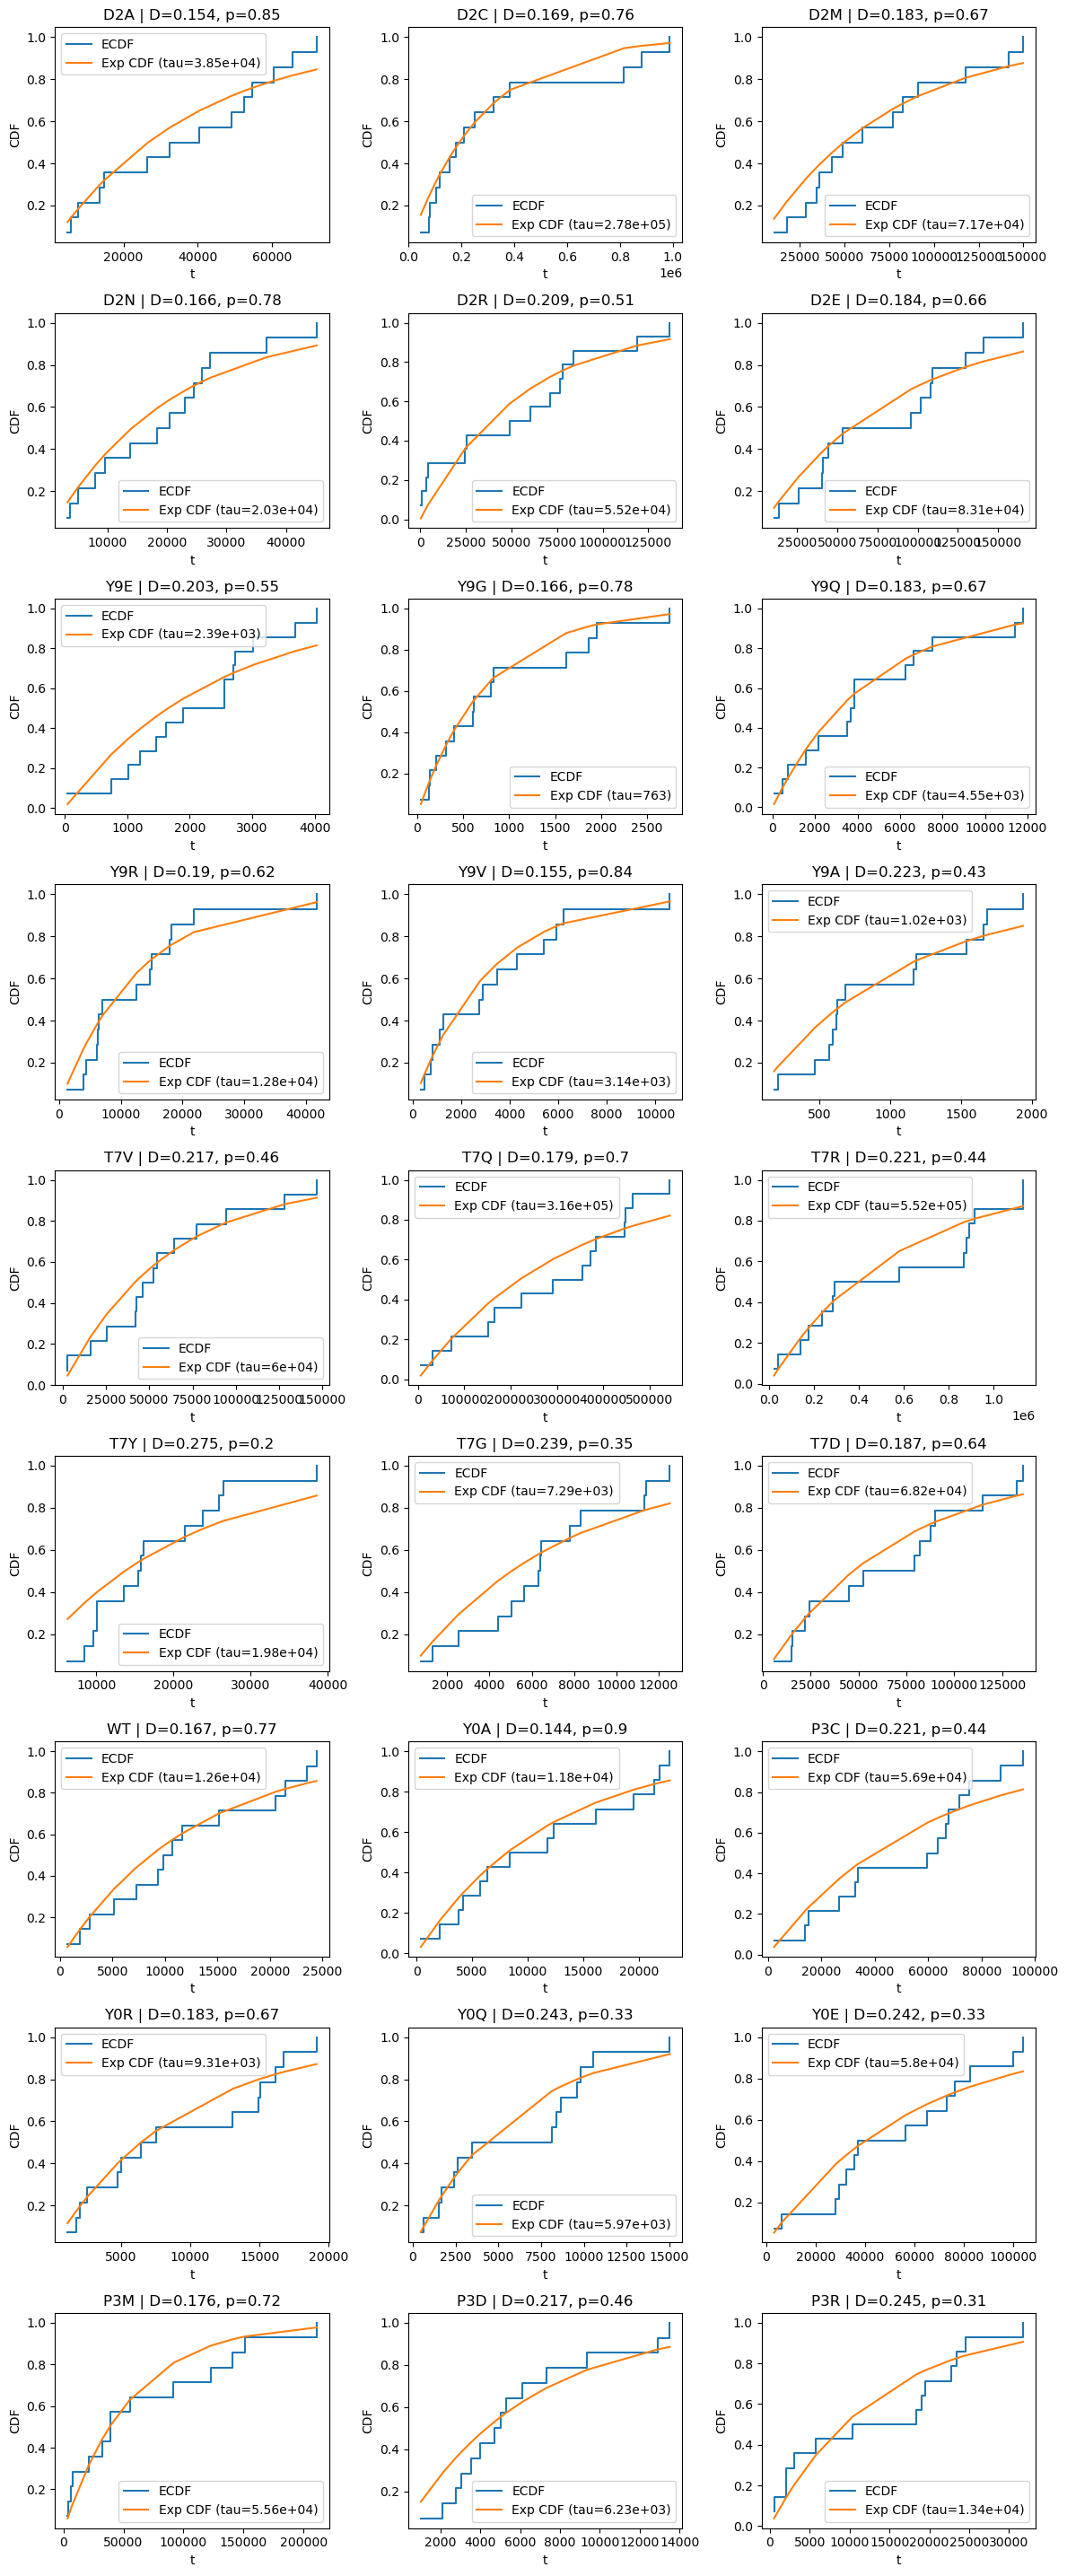

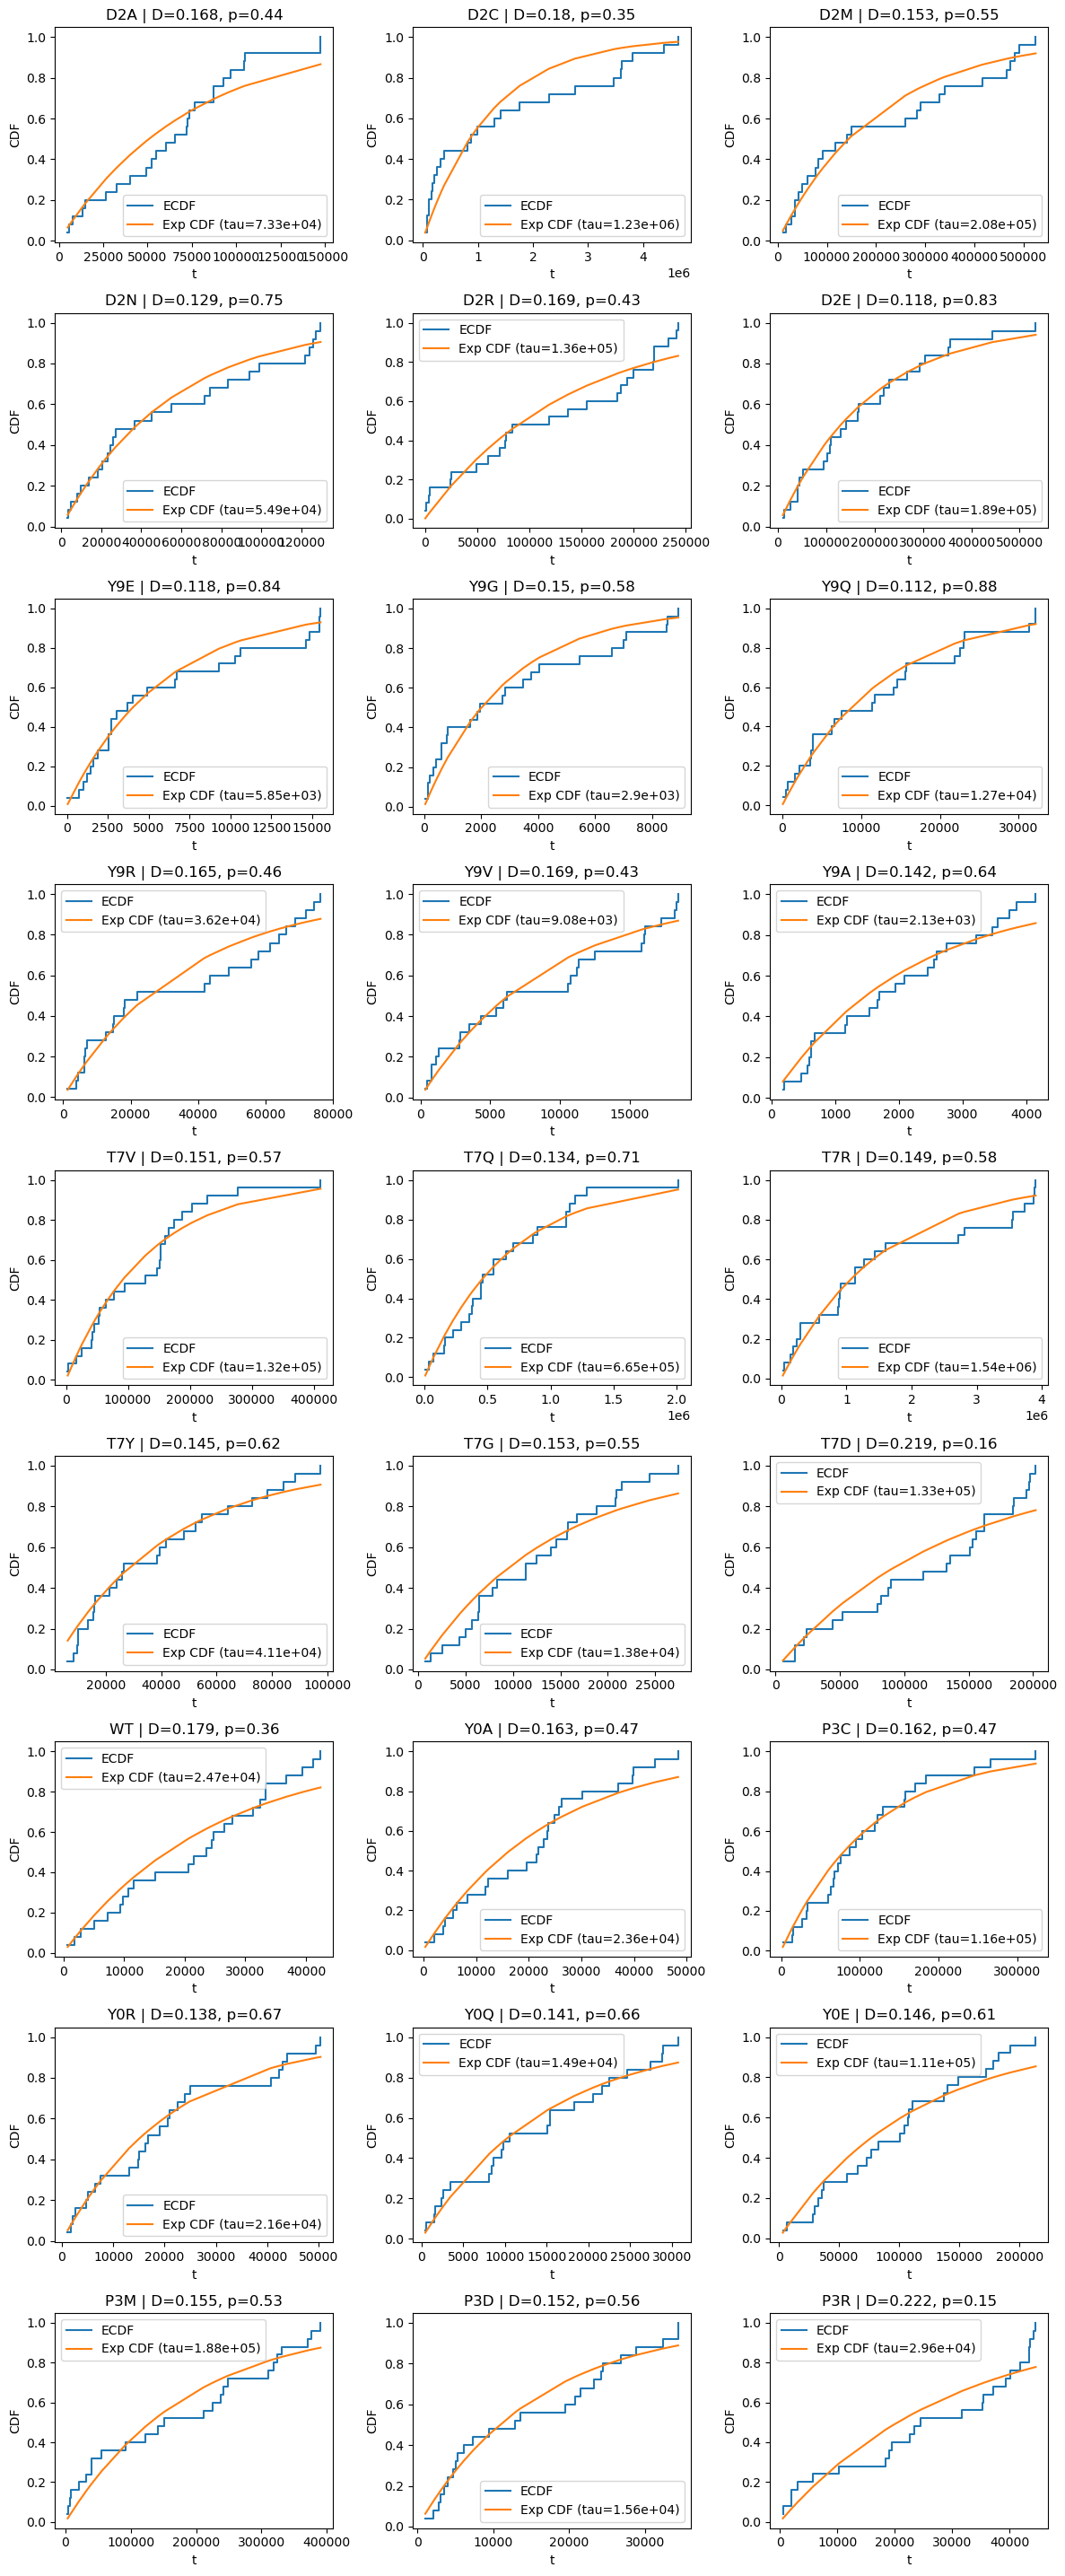

      name  k_fixed    tau_fixed  D_fixed  p_fixed  k_dyn       tau_dyn    D_dyn    p_dyn
YYAPETGTWY       25 7.331481e+04 0.167583 0.436422     14  38464.831865 0.154028 0.845523
YYCPETGTWY       25 1.232838e+06 0.180036 0.349887     11 188573.016359 0.241818 0.468849
YYMPETGTWY       25 2.083068e+05 0.152802 0.552572     11  52785.906343 0.233061 0.515208
YYNPETGTWY       25 5.494737e+04 0.128716 0.754896     11  14985.150830 0.194574 0.731180
YYRPETGTWY       25 1.364082e+05 0.168894 0.426777     35 205345.641021 0.176712 0.199200
YYEPETGTWY       25 1.886313e+05 0.118445 0.834348     15  90473.350175 0.186754 0.607268
YYDPETGTWE       25 5.847341e+03 0.117654 0.840019     15   2588.006282 0.190326 0.583908
YYDPETGTWG       25 2.896479e+03 0.150052 0.575373     10    411.010277 0.172156 0.881266
YYDPETGTWQ       25 1.268974e+04 0.112417 0.875568     12   3503.657475 0.218265 0.545533
YYDPETGTWR       25 3.617549e+04 0.164981 0.455923     13  11333.140277 0.212538 0.531048
YYDPETGTWV

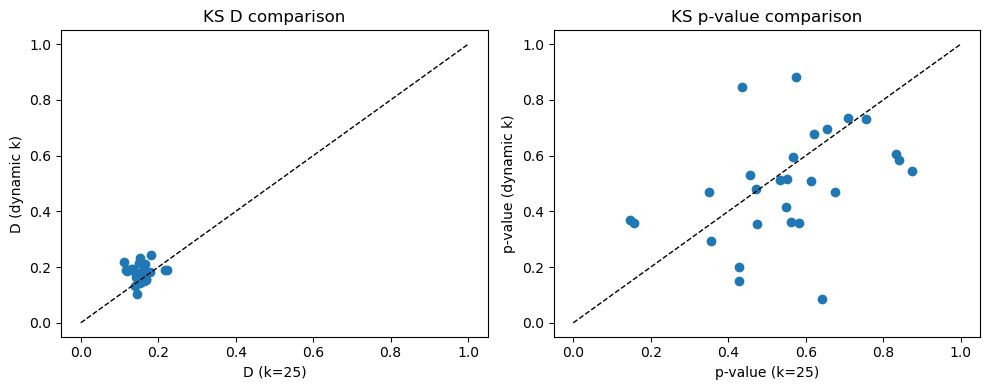

In [ ]:
import math 

def fit_exp_ecdf(samples, ax):
    x = np.array(samples)

    n = x.size
    def F(t, tau): return 1 - np.exp(-t / tau)
    ecdf = np.arange(1, n + 1) / n
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    th = stats.expon.cdf(x, scale=tau)

    ax.step(x, ecdf, where="post", label="ECDF")
    ax.plot(x, th, label=f"Exp CDF (tau={tau:.3g})")
    D, p = stats.kstest(x, "expon", args=(0, tau))
    ax.set_xlabel("t"); ax.set_ylabel("CDF"); ax.legend(); ax.set_title(f"D={D:.3g}, p={p:.2g}")
    return tau, D, p, ax

def ks_table_fastest_k(all_mfpt, names, th, k):
    rows = []
    for name in names:
        s = np.array(all_mfpt[name][th])
        s.sort()
        
        s = s[:k]
        tau, p, D = fit_exp_ks(s)
        rows.append({"name": name, "n": s.size, "tau": tau, "ks_p": p, "ks_D": D})
    return pd.DataFrame(rows).sort_values("ks_p", ascending=False)

def plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k = None ):
    ncols=3
    m = len(names)
    nrows = math.ceil(m / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), squeeze=False)
    for i, name in enumerate(names):
        r, c = divmod(i, ncols)
        if k == None:
            mfpt_base, k = estimateMFPT(np.array(all_mfpt[name][th]), 10)
            print(mfpt_base, k)

        s = np.sort(np.array(all_mfpt[name][th]))[:k]
        fit_exp_ecdf(s, ax=axes[r, c])
        axes[r, c].set_title(f"{mutation_map[name]} | " + axes[r, c].get_title())
        
    fig.tight_layout()
    return fig

th = np.array(list(all_mfpt['chignolin'].keys()))[2]
print(th)
names = list(proteins)
k = 25
res = ks_table_fastest_k(all_mfpt, names, th, k = k)

plot_ecdfs_grid_fastest_k(all_mfpt, names, th)
plt.show()

plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k = k)
plt.show()

def compare_k_vs_dynamic(all_mfpt, names, th, k = k):
    rows = []
    for name in names:
        s_all = np.sort(np.array(all_mfpt[name][th]))

        s_fixed = s_all[:k]
        fig, ax = plt.subplots()
        tau_f, D_f, p_f, _ = fit_exp_ecdf(s_fixed, ax=ax)
        plt.close(fig)

        # Dynamic k from estimateMFPT
        _, k_dyn = estimateMFPT(s_all, 10)
        s_dyn = s_all[:k_dyn]
        fig, ax = plt.subplots()
        tau_d, D_d, p_d, _ = fit_exp_ecdf(s_dyn, ax=ax)
        plt.close(fig)

        rows.append({
            "name": name,
            "k_fixed": k, "tau_fixed": tau_f, "D_fixed": D_f, "p_fixed": p_f,
            "k_dyn": k_dyn, "tau_dyn": tau_d, "D_dyn": D_d, "p_dyn": p_d
        })

    df = pd.DataFrame(rows)
    print(df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(df["D_fixed"], df["D_dyn"])
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_xlabel(f"D (k={k})")
    axes[0].set_ylabel("D (dynamic k)")
    axes[0].set_title("KS D comparison")

    axes[1].scatter(df["p_fixed"], df["p_dyn"])
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel(f"p-value (k={k})")
    axes[1].set_ylabel("p-value (dynamic k)")
    axes[1].set_title("KS p-value comparison")

    fig.tight_layout()
    return df, fig

df_comparison, fig_cmp = compare_k_vs_dynamic(all_mfpt, names, th)
plt.show()


In [ ]:
# %load_ext autoreload
# %autoreload 2

# from pathlib import Path
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import optimize, stats
# from common.utils import estimateMFPT
# import warnings

# warnings.filterwarnings("ignore", category=FutureWarning)

# PROTEINS = ['YYAPETGTWY','YYCPETGTWY','YYDPETGQWY', 'YYDPETGRWY']
# RANGES = [(4000, 4200), (3000, 3200), (3201, 3400)]
# THRESHOLDS = np.round(np.arange(0.1, 0.5 + 1e-9, 0.05), 2)

# def read_colvar(path: Path) -> pd.DataFrame:
#     with path.open() as f:
#         for line in f:
#             if line.startswith("#! FIELDS"):
#                 names = line.replace("#! FIELDS", "").strip().split()
#                 break
#         else:
#             raise ValueError(f"No FIELDS header in {path}")
#     return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

# def first_cross_times(df: pd.DataFrame, thresholds):
#     rmsd = df['rmsd'].to_numpy()
#     t = df['time'].to_numpy()
#     acc = df['metad.acc'].to_numpy()
#     out = {}
#     for th in thresholds:
#         idx = np.flatnonzero(rmsd > th)
#         out[float(th)] = None if idx.size == 0 else float(t[idx[0]] * acc[idx[0]])
#     return out

# def fit_tau_and_pvalue(samples):
#     x = np.array(sorted(samples, key=float))
#     n = len(x)
#     ecdf = np.arange(1, n + 1) / n
#     tau = optimize.curve_fit(lambda tt, tau: 1 - np.exp(-tt / tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
#     f = np.random.exponential(tau, size=max(10000, 10*n))
#     p = stats.ks_2samp(x, f, alternative="two-sided", method="asymp")[1]
#     return tau, p

# def gather_samples_multi(protein: str, start: int, stop: int, thresholds):
#     base = Path(f"../data/{protein}/output")
#     buckets = {float(th): [] for th in thresholds}
#     for i in range(start, stop):
#         p = base / f"run_{i}" / f"HLDA_COLVAR_{i}"
#         if not p.exists():
#             print(f"Missing file: {p}")
#             continue
#         df = read_colvar(p)
#         crosses = first_cross_times(df, thresholds)
#         for th, val in crosses.items():
#             if val is not None:
#                 buckets[th].append(val)
#     rows = []
#     for th, arr in buckets.items():
#         if not arr:
#             rows.append(dict(thresh=th, mfpt=None, k=None, pvalue=None, n=0))
#             continue
#         arr = np.array(arr, float)
#         mfpt, k = estimateMFPT(arr, 15)
#         tau, pval = fit_tau_and_pvalue(arr)
#         rows.append(dict(thresh=th, mfpt=mfpt, k=k, pvalue=pval, n=len(arr)))
#     return pd.DataFrame(rows)

# all_rows = []
# for protein in PROTEINS:
#     for (a, b) in RANGES:
#         res = gather_samples_multi(protein, a, b, THRESHOLDS)
#         res['protein'] = protein
#         res['start'] = a
#         res['stop'] = b
#         all_rows.append(res)

# res = pd.concat(all_rows, ignore_index=True)
# print(res)

# fig1, axes1 = plt.subplots(len(PROTEINS), 1, figsize=(6, 4*len(PROTEINS)), squeeze=False)
# for ax, protein in zip(axes1.ravel(), PROTEINS):
#     sub = res[(res.protein==protein) & res.mfpt.notna()]
#     for (a,b), g in sub.groupby(["start","stop"]):
#         g = g.sort_values("thresh")
#         ax.plot(g.thresh, g.mfpt*1e-6, marker="o", label=f"{a}-{b-1}")
#     ax.set_title(f"{protein} — MFPT vs threshold")
#     ax.set_xlabel("threshold")
#     ax.set_ylabel("MFPT (µs)")
#     ax.legend()
# plt.tight_layout()
# plt.show()

# fig2, axes2 = plt.subplots(len(PROTEINS), 1, figsize=(6, 4*len(PROTEINS)), squeeze=False)
# for ax, protein in zip(axes2.ravel(), PROTEINS):
#     sub = res[(res.protein==protein) & res.pvalue.notna()]
#     for (a,b), g in sub.groupby(["start","stop"]):
#         g = g.sort_values("thresh")
#         ax.plot(g.thresh, g.pvalue, marker="s", label=f"{a}-{b-1}")
#     ax.set_title(f"{protein} — KS p-value vs threshold")
#     ax.set_xlabel("threshold")
#     ax.set_ylabel("p-value")
#     ax.legend()
# plt.tight_layout()
# plt.show()


/rg/mendels_prj/alexander.z/protein-toolkit/src/common/utils.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)
/rg/mendels_prj/alexander.z/protein-toolkit/src/common/utils.py:45: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)


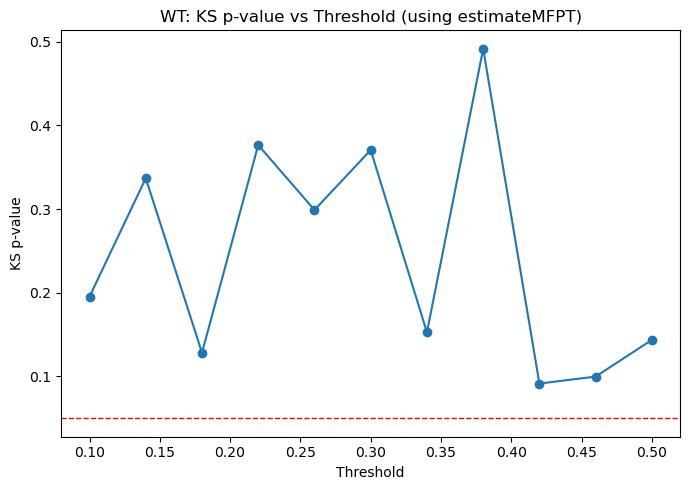